In [73]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

### "Model Training Phase" begins.

In [88]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
     62/Unknown 55s 540ms/step - accuracy: 0.6295 - loss: 0.7999

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 72s 809ms/step - accuracy: 0.6496 - loss: 0.7406 - val_accuracy: 0.8519 - val_loss: 0.4325
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.7488 - loss: 0.5650 - val_accuracy: 0.8565 - val_loss: 0.3829
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.7785 - loss: 0.5313 - val_accuracy: 0.8681 - val_loss: 0.3497
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 380ms/step - accuracy: 0.7923 - loss: 0.4880 - val_accuracy: 0.8681 - val_loss: 0.3306
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.8092 - loss: 0.4451 - val_accuracy: 0.8727 - val_loss: 0.3227
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 372ms/step - accuracy: 0.8220 - loss: 0.4425 - val_accuracy: 0.8657 - val_loss: 0.3129
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 389ms/step - accuracy: 0.8205 - loss: 0.4323 - val_accuracy: 0.8773 - val_loss: 0.3052
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.8292 - loss: 0.4126 - val_accuracy: 0.877

### Fine-Tuning

In [89]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 75s 763ms/step - accuracy: 0.7923 - loss: 0.4517 - val_accuracy: 0.8819 - val_loss: 0.3062
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - accuracy: 0.8056 - loss: 0.4449 - val_accuracy: 0.8796 - val_loss: 0.3158
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 367ms/step - accuracy: 0.8026 - loss: 0.4530 - val_accuracy: 0.8727 - val_loss: 0.3232
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - accuracy: 0.8061 - loss: 0.4335 - val_accuracy: 0.8681 - val_loss: 0.3273
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - accuracy: 0.8123 - loss: 0.4429 - val_accuracy: 0.8681 - val_loss: 0.3304


### "Final Model Evaluation".

In [90]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

           0       0.67      0.30      0.41        67
           1       0.88      0.97      0.93       365

    accuracy                           0.87       432
   macro avg       0.77      0.64      0.67       432
weighted avg       0.85      0.87      0.85       432



### "Learning Curves Analysis".

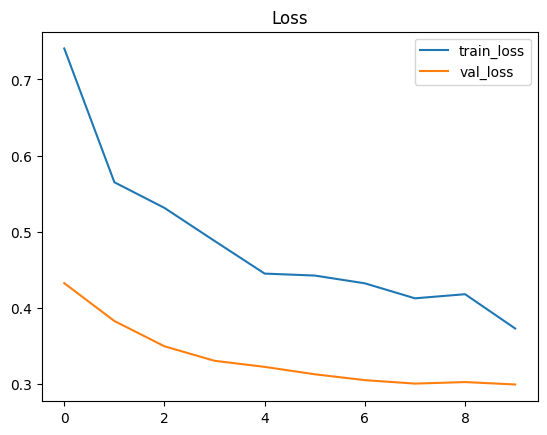

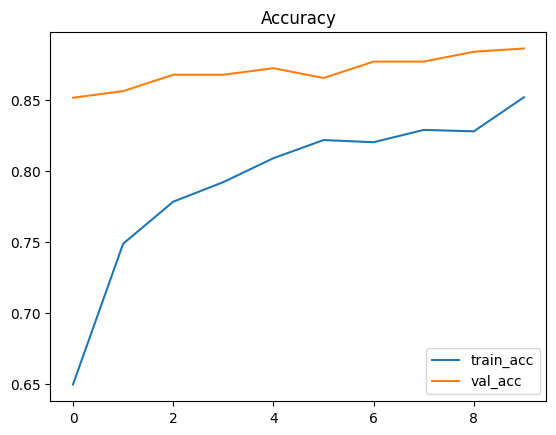

In [91]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

### "Confusion Matrix"
#### The matrix divides the results into four main quadrants:
#### True Positives (TP): The number of cases that were "fractured" and predicted by the model (Excellent).
#### True Negatives (TN): The number of cases that were "healthy" and predicted by the model (Excellent).
#### False Positives (FP): The number of cases that were "healthy" but the model incorrectly identified them as "fractured."
#### False Negatives (FN): (Medically the most serious) The number of cases that were actually "fractured" but the 
#### model incorrectly identified them as "healthy."

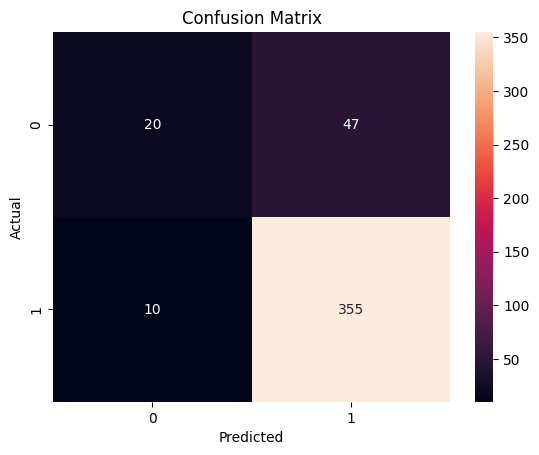

In [92]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### "Metrics Visualization" (Metrics Comparison Analysis).

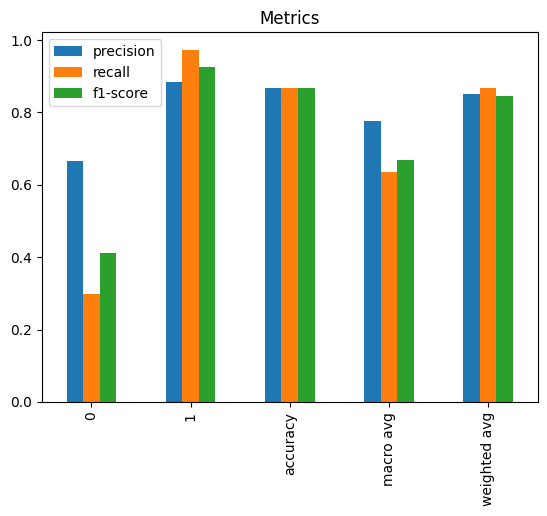

In [93]:
report = classification_report(y_true, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

df[['precision','recall','f1-score']].plot(kind='bar')
plt.title("Metrics")
plt.show()

### "Model Saving and Exporting".

In [ ]:
model.save("fracture_model_tf.h5")

### "Prediction Function" (Inference Function)

In [94]:
import cv2

def predict(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]
    return "Fractured" if pred > 0.5 else "Normal"